# Two level rabi oscillations

Two level Rabi oscillations, or Givens rotations, are generated by activating only one NMR or NER drive tone, resonant with the energy difference (Larmor frequency) of a specific two level pair.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from psyduck import Spin
from psyduck.operations import nmr1_hamiltonian
from psyduck.fit_toolbox import SineFit

In [2]:
subspaces = [[i, i-1] for i in np.arange(7/2, -7/2, -1)]
nucleus = Spin(I=7/2)

In [3]:
B1 = [1, 0, 0, 0, 0, 0, 0]
H_rf = nmr1_hamiltonian(7/2, B1, gamma=-5.55) # MHz

In [4]:
H_rf

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.         7.34195989 0.         0.         0.         0.
  0.         0.        ]
 [7.34195989 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

In [5]:
times = np.arange(0, 1, 0.001)
nucleus.make_eigenstate(7/2) # initialize nuclear eigenstate
trajectory = nucleus.evolve(H_rf, times)

In [6]:
trajectory

SpinSeries(I=3.5, N=1000, coords=0..0.999)

In [7]:
nucleus.state_labels()

['|7/2>', '|5/2>', '|3/2>', '|1/2>', '|-1/2>', '|-3/2>', '|-5/2>', '|-7/2>']

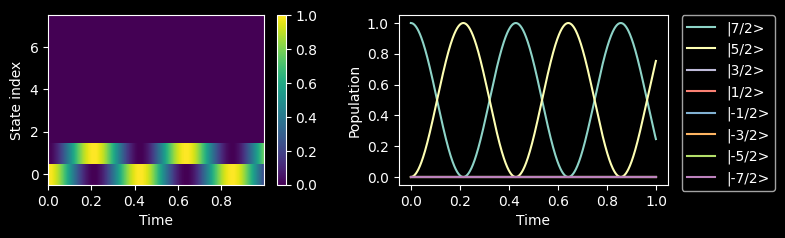

In [12]:
populations = trajectory.populations()

def plot_populations(populations):
    fig, ax = plt.subplots(1,2, figsize=(8,2.2), gridspec_kw={'wspace':0.3})
    pcm = ax[0].pcolor(times, np.arange(8), populations.T)
    for i in range(populations.shape[1]):
        ax[1].plot(times, populations[:, i], label=nucleus.state_labels()[i])
    ax[1].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.colorbar(pcm, ax=ax[0])

    ax[0].set_ylabel('State index')
    ax[0].set_xlabel('Time')

    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Population')

plot_populations(populations)

# Compare Rabi frequencies

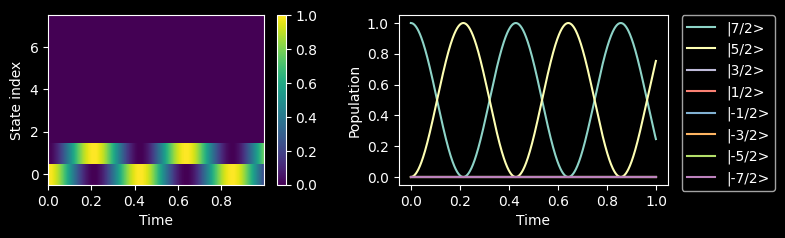

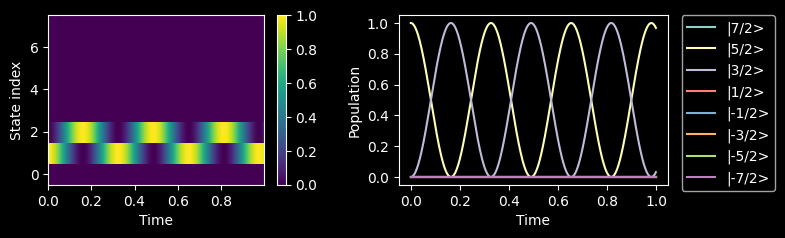

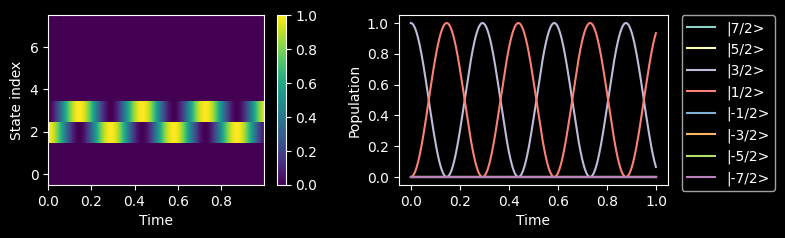

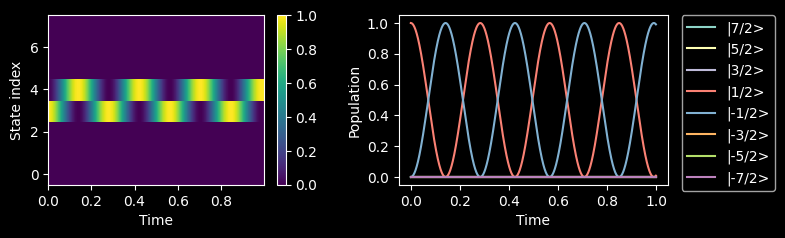

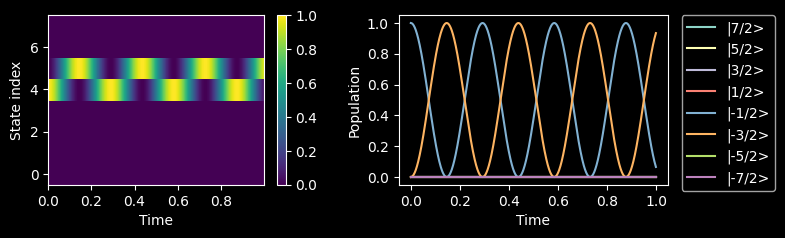

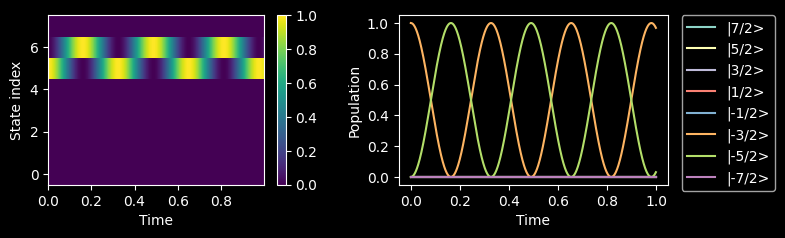

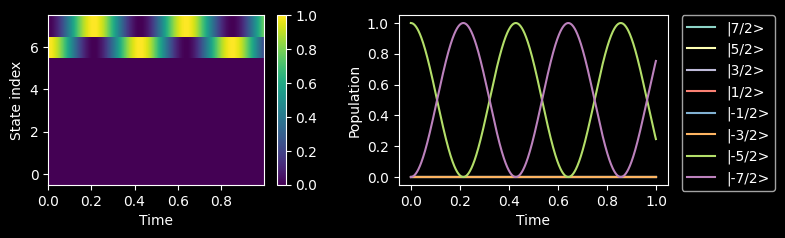

In [22]:
rabi_frequencies = np.zeros(7)

for i in range(0, 7):
    B1 = np.zeros(7)
    times = np.arange(0, 1, 0.001)
    nucleus.make_eigenstate(7/2-i) # initialize nuclear eigenstate
    B1[i] = 1 # activate one drive tone
    H_rf = nmr1_hamiltonian(7/2, B1, gamma=-5.55) # MHz
    trajectory = nucleus.evolve(H_rf, times)
    populations = trajectory.populations()
    plot_populations(populations)
    rabi_fit = SineFit(populations[:, i], xvals=times)
    rabi_frequencies[i] = rabi_fit.fit_result.params['frequency']

Text(0, 0.5, 'Rabi Frequency')

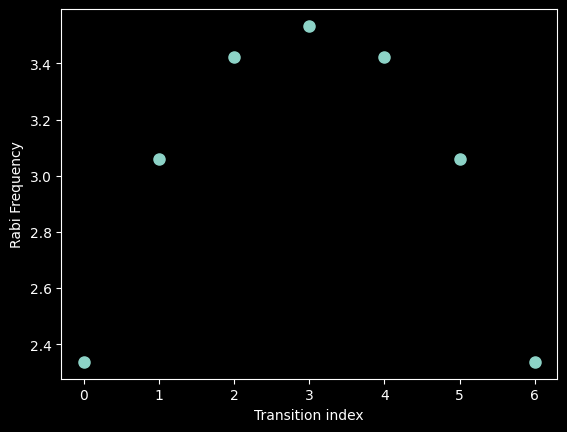

In [28]:
plt.plot(np.arange(0, 7), rabi_frequencies, 'o', markersize=8)
plt.xlabel('Transition index')
plt.ylabel('Rabi Frequency')

In [29]:
# to do two level NER